
# **Marketing Data Analysis**

# *1.Import Libraries*

In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px

# *2. Load Dataset*

In [131]:
df = pd.read_csv(r"C:\Users\sujal\Downloads\Marketing_data.csv")

# *3. Exploring Data*

In [132]:
df.head()

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,...,111,189,218,1,4,4,6,1,1,0
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,...,7,0,37,1,7,3,7,5,1,0
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,...,15,2,30,1,3,2,5,2,0,0
3,1386,1967,Graduation,Together,32474.0,1,1,11/5/2014,0,10,...,0,0,0,1,1,0,2,7,0,0
4,5371,1989,Graduation,Single,21474.0,1,0,8/4/2014,0,6,...,11,0,34,2,3,1,2,7,1,0


In [133]:
print("Dataset Shape:", df.shape)

Dataset Shape: (2240, 22)


In [134]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Id                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Response                0
Complain                0
dtype: int64


In [135]:
print("Data Types:")
print(df.dtypes)

Data Types:
Id                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
Response                 int64
Complain                 int64
dtype: object


# *4.Data Cleaning*

In [136]:
df['Income'] = df['Income'].fillna(df['Income'].median())

In [137]:
print(df.isnull().sum())

Id                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Response               0
Complain               0
dtype: int64


In [138]:
columns_to_remove = ['Id','Dt_Customer','Complain','Year_Birth','Marital_Status','Kidhome','Teenhome','Recency']
df = df.drop(columns=columns_to_remove)

In [139]:
df.head()

,Education,Income,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response
0,Graduation,84835.0,189,104,379,111,189,218,1,4,4,6,1,1
1,Graduation,57091.0,464,5,64,7,0,37,1,7,3,7,5,1
2,Graduation,67267.0,134,11,59,15,2,30,1,3,2,5,2,0
3,Graduation,32474.0,10,0,1,0,0,0,1,1,0,2,7,0
4,Graduation,21474.0,6,16,24,11,0,34,2,3,1,2,7,1


**Total Spending Column**

In [140]:
df['Total_Spending'] = ( df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds'])


In [141]:
print("Dataset Statistics:")
df.describe() 

Dataset Statistics:


,Income,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Total_Spending
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,52237.975446,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.149107,605.798214
std,25037.955891,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.356274,602.249288
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000
25%,35538.750000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,68.750000
50%,51381.500000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,396.000000
75%,68289.750000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,1045.500000
max,666666.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,2525.000000


In [142]:
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
df = df[(df['Income'] >= lower_limit) &(df['Income'] <= upper_limit)]
print("Outliers Removed Successfully 1st time")

Outliers Removed Successfully 1st time


In [143]:
print(df['Income'].sort_values(ascending=False).head())
df = df[df['Income'] < 110000]

210     113734.0
832     105471.0
142     102692.0
1244    102160.0
1564    101970.0
Name: Income, dtype: float64


# *5. Feature Engineering*

In [144]:
channel_performance = {'Store': df['NumStorePurchases'].sum(),'Web': df['NumWebPurchases'].sum(),'Catalog': df['NumCatalogPurchases'].sum(),'Deals': df['NumDealsPurchases'].sum()}

In [145]:
channel_df = pd.DataFrame(channel_performance.items(),columns=['Channel', 'Purchases'])
print(channel_df)

   Channel  Purchases
0    Store      12964
1      Web       9119
2  Catalog       5884
3    Deals       5174


# *6.EDA*

In [146]:
response_counts = df['Response'].value_counts()
fig = px.pie(values=response_counts.values, names=['Rejected', 'Accepted'],title='Campaign Response Distribution')
fig.show()

In [147]:
fig = px.scatter(df,x='Income', y='Total_Spending',color='Education', title='Income vs Total Spending')
fig.show()

In [148]:
fig = px.bar( channel_df, x='Channel', y='Purchases',title='Marketing Channel Performance',text='Purchases')
fig.show()

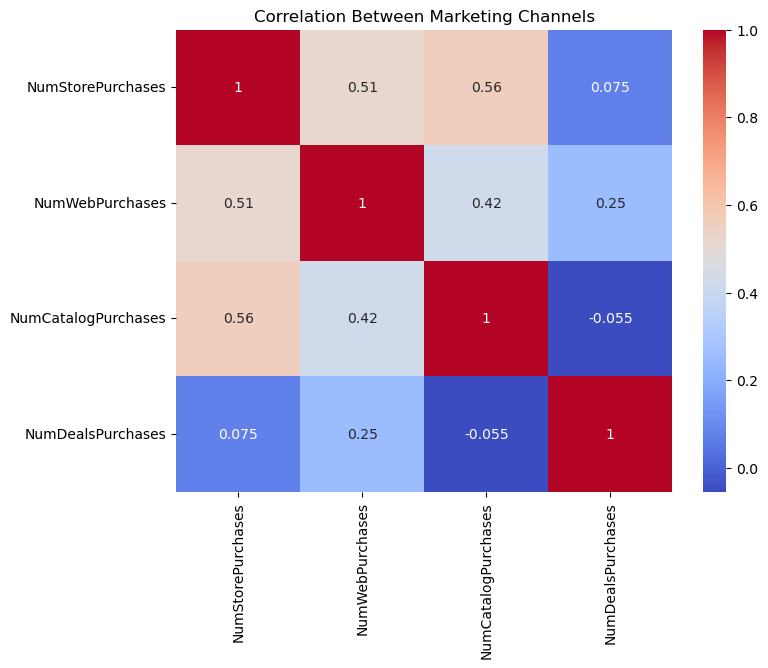

In [156]:
channel_data = df[['NumStorePurchases','NumWebPurchases','NumCatalogPurchases','NumDealsPurchases']]
plt.figure(figsize=(8,6))
sns.heatmap(channel_data.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Between Marketing Channels")
plt.show()

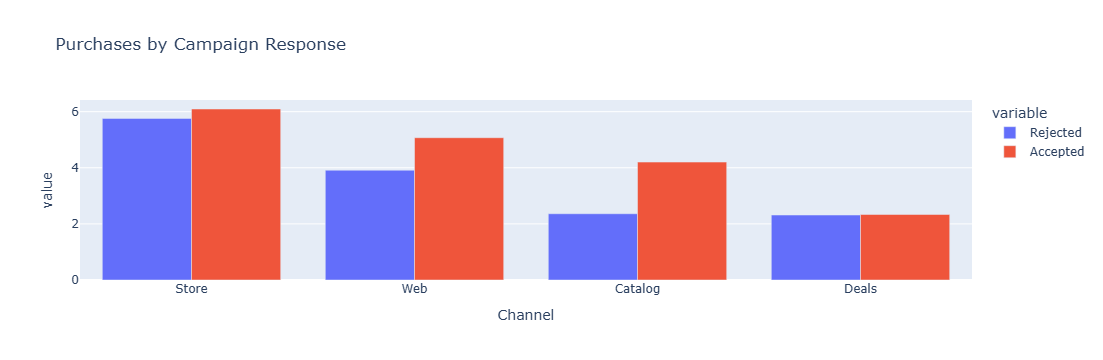

In [167]:
channel_response = df.groupby('Response')[ ['NumStorePurchases','NumWebPurchases','NumCatalogPurchases','NumDealsPurchases']].mean().T.reset_index()
channel_response.columns = ['Channel', 'Rejected', 'Accepted']
channel_response['Channel'] = ['Store','Web','Catalog','Deals']
fig = px.bar(channel_response,x='Channel', y=['Rejected', 'Accepted'],barmode='group',title='Purchases by Campaign Response')
fig.show()

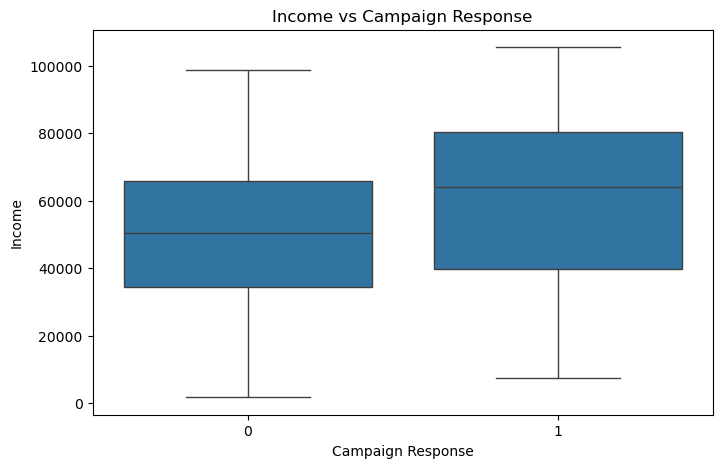

In [150]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Response',y='Income',data=df)
plt.title("Income vs Campaign Response")
plt.xlabel("Campaign Response")
plt.ylabel("Income")
plt.show()

In [170]:
df.to_csv('Marketing_Campaign_Data.csv', index=False)